# Conditional Distance-CRP

> Compute and visualize distance-binned conditional response probabilities with transition filtering.

The conditional Distance-CRP extends the standard Distance-CRP by adding a `should_tabulate` mask that controls which transitions are counted. When `should_tabulate[i]` is False for a recall event, the tabulator still updates internal state (availability, previous item) but does **not** increment actual or available bin tallies for that transition.

$$\text{CRP}(d) = \frac{\text{actual transitions in distance bin } d}{\text{available transitions in distance bin } d}$$

This is useful for analyses that need to exclude specific transitions while preserving correct availability tracking. Distance bins are computed from cosine similarity of semantic embeddings.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty to skip) |
| `ylim` | Y-axis limits or `None` for auto |
| `trial_query` | Query string for trial selection |
| `features_path` | Path to numpy feature embeddings |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxcmr.analyses.conditional_distcrp import (
    DistanceTabulation,
    dist_crp,
    plot_dist_crp,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.math import cosine_similarity_matrix

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
features_path = "data/peers-all-mpnet-base-v2.npy"

In [4]:
#| code-summary: Load data and construct should_tabulate mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
features = np.load(os.path.join(project_root, features_path)).astype(np.float32)

# Construct should_tabulate: tabulate all valid recalls
should_tabulate = data["recalls"] > 0

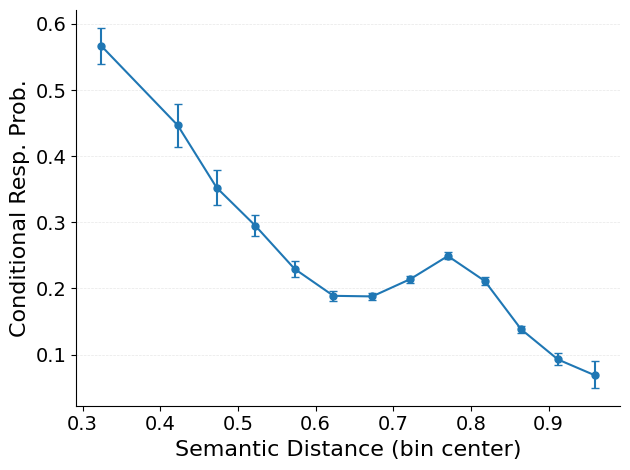

In [5]:
#| code-summary: Plot Conditional Distance-CRP
#| label: fig-conditional-distcrp
#| fig-cap: "Conditional Distance-CRP showing response probability by semantic distance bin."
plot_dist_crp(
    data,
    trial_mask,
    should_tabulate=should_tabulate,
    features=features,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_dist_crp)

---

### plot_dist_crp

>      plot_dist_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDataset],jaxcm
>                     r.typing.RecallDataset], trial_masks:Union[Sequence[jaxtyp
>                     ing.Bool[Array,'trial_count']],jaxtyping.Bool[Array,'trial
>                     _count']], should_tabulate:Union[Sequence[jaxtyping.Bool[A
>                     rray,'trial_countrecall_events']],jaxtyping.Bool[Array,'tr
>                     ial_countrecall_events']], features:jaxtyping.Float[Array,
>                     'word_countfeatures_count'],
>                     color_cycle:Optional[list[str]]=None,
>                     labels:Optional[Sequence[str]]=None,
>                     contrast_name:Optional[str]=None,
>                     axis:Optional[matplotlib.axes._axes.Axes]=None,
>                     min_transitions_per_subject:int=10, bin_step:float=0.05,
>                     bin_source_index:int=0,
>                     bin_edges:Optional[jaxtyping.Float[Array,'edges']]=None,
>                     bin_centers:Optional[jaxtyping.Float[Array,'bins']]=None,
>                     confidence_level:float=0.95)

*Plot distance-binned CRP with conditional tabulation.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Recall datasets to contrast. |
| trial_masks | Union |  | Boolean masks selecting trials per dataset. |
| should_tabulate | Union |  | Boolean masks aligned to recall events. |
| features | Float[Array, 'word_count features_count'] |  | Feature matrix aligned with vocabulary items. |
| color_cycle | Optional | None | Colors for successive datasets. |
| labels | Optional | None | Legend labels for ``datasets``. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing matplotlib Axes to plot on. |
| min_transitions_per_subject | int | 10 | Minimum available transitions per bin per subject. |
| bin_step | float | 0.05 | Distance increment for expanding each bin. |
| bin_source_index | int | 0 | Dataset index providing binning availability. |
| bin_edges | Optional | None | Interior bin edges; computed if ``None``. |
| bin_centers | Optional | None | Bin centers matching ``bin_edges``. |
| confidence_level | float | 0.95 | Confidence level for the bounds. |
| **Returns** | **Axes** |  | **Axes with distance-binned CRP curves.** |

In [7]:
# plot_dist_crp returns an Axes object
from matplotlib.axes import Axes

ax = plot_dist_crp(data, trial_mask, should_tabulate=should_tabulate, features=features)
assert isinstance(ax, Axes)
plt.close()

In [8]:
#| echo: false
show_doc(dist_crp)

---

### dist_crp

>      dist_crp (dataset:jaxcmr.typing.RecallDataset,
>                distance_matrix:jaxtyping.Float[Array,'item_countitem_count'],
>                bin_edges:jaxtyping.Float[Array,'edges'])

*Return distance-conditioned CRP with transition filtering.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| dataset | RecallDataset | Dataset with ``recalls``, ``pres_itemids``, and<br>``_should_tabulate``. |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise item distances. |
| bin_edges | Float[Array, 'edges'] | Interior boundaries for distance bins. |
| **Returns** | **Float[Array, 'bins']** | **Conditional response probability per distance bin.** |

In [9]:
# dist_crp returns one value per distance bin
from jaxcmr.analyses.distcrp import compute_distance_bins_min_count

distances = 1 - cosine_similarity_matrix(features)
edges, centers = compute_distance_bins_min_count(
    data, distances, min_transitions_per_subject=10, trial_mask=trial_mask
)

data_with_mask = {**data, "_should_tabulate": should_tabulate}
result = dist_crp(data_with_mask, distances, edges)
assert result.shape[0] == edges.shape[0] + 1

In [10]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (trial:jaxtyping.Integer[Array,'recall_events'],
>                      present_ids:jaxtyping.Integer[Array,'study_item_ids'],
>                      should_tabulate:jaxtyping.Bool[Array,'recall_events'], di
>                      stance_matrix:jaxtyping.Float[Array,'item_countitem_count
>                      '], bin_edges:jaxtyping.Float[Array,'edges'])

*Return actual and available bin counts for a trial.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| trial | Integer[Array, 'recall_events'] | Recall events as study positions. |
| present_ids | Integer[Array, 'study_item_ids'] | Item identifiers at each study position. |
| should_tabulate | Bool[Array, 'recall_events'] | Boolean mask; True counts the transition. |
| distance_matrix | Float[Array, 'item_count item_count'] | Pairwise distances indexed by item identifier. |
| bin_edges | Float[Array, 'edges'] | Interior bin edges shared across trials. |
| **Returns** | **tuple** | **Actual and available transition counts per bin.** |

In [11]:
# tabulate_trial returns a pair of bin-count arrays
trial = jnp.array([1, 2, 3], dtype=jnp.int32)
present_ids = jnp.array([10, 20, 30], dtype=jnp.int32)
mask = jnp.array([True, True, True], dtype=bool)
test_edges = jnp.array([0.5], dtype=jnp.float32)
n_items = 50
test_dist = jnp.ones((n_items, n_items), dtype=jnp.float32) * 0.3

actual, avail = tabulate_trial(trial, present_ids, mask, test_dist, test_edges)
assert actual.shape == (2,)  # 1 edge -> 2 bins
assert avail.shape == (2,)